In [1]:
## DELTAKIT STIM ##
import deltakit_stim
# Deltakit circuit clashes with deltakit_stim unless do these injections
injections = ['stim._detect_machine_architecture', 'stim._stim_polyfill', 'stim']
import sys
for namespace in injections:
    sys.modules[namespace] = sys.modules[f"deltakit_{namespace}"]


## BB_IONS ##
import os
sys.path.append(os.path.abspath("../src"))
from bb_ions import *

<class 'deltakit_stim._stim_polyfill.Circuit'>


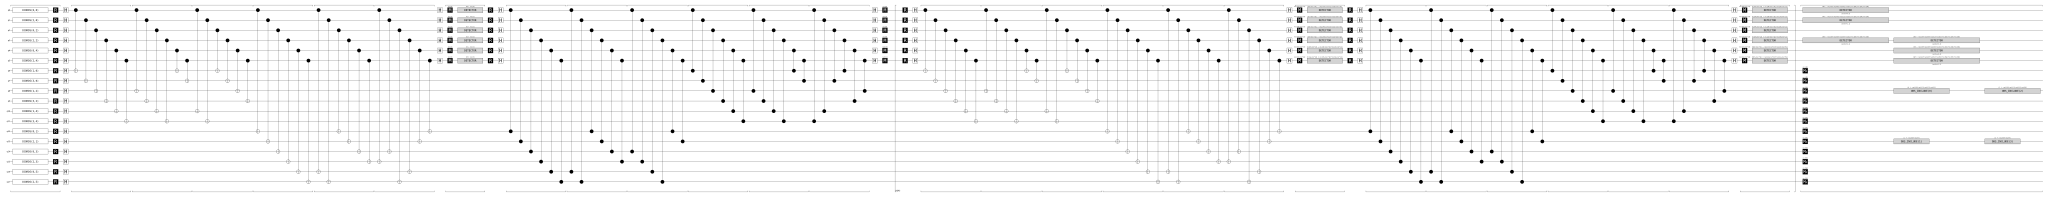

QUBIT_COORDS(0, 0) 0
QUBIT_COORDS(2, 0) 1
QUBIT_COORDS(0, 2) 2
QUBIT_COORDS(2, 2) 3
QUBIT_COORDS(0, 4) 4
QUBIT_COORDS(2, 4) 5
QUBIT_COORDS(1, 0) 6
QUBIT_COORDS(3, 0) 7
QUBIT_COORDS(1, 2) 8
QUBIT_COORDS(3, 2) 9
QUBIT_COORDS(1, 4) 10
QUBIT_COORDS(3, 4) 11
QUBIT_COORDS(0, 1) 12
QUBIT_COORDS(2, 1) 13
QUBIT_COORDS(0, 3) 14
QUBIT_COORDS(2, 3) 15
QUBIT_COORDS(0, 5) 16
QUBIT_COORDS(2, 5) 17
R 0 1 2 3 4 5
X_ERROR(0.001) 0 1 2 3 4 5
R 6 7 8 9 10 11 12 13 14 15 16 17
X_ERROR(0.001) 6 7 8 9 10 11 12 13 14 15 16 17
TICK
H 0 1 2 3 4 5
DEPOLARIZE1(0.001) 0 1 2 3 4 5
H 6 7 8 9 10 11 12 13 14 15 16 17
DEPOLARIZE1(0.001) 6 7 8 9 10 11 12 13 14 15 16 17
TICK
CX 0 6
DEPOLARIZE2(0.001) 0 6
CX 1 7
DEPOLARIZE2(0.001) 1 7
CX 2 8
DEPOLARIZE2(0.001) 2 8
CX 3 9
DEPOLARIZE2(0.001) 3 9
CX 4 10
DEPOLARIZE2(0.001) 4 10
CX 5 11
DEPOLARIZE2(0.001) 5 11
DEPOLARIZE1(0.001) 12 13 14 15 16 17
TICK
CX 0 8
DEPOLARIZE2(0.001) 0 8
CX 1 9
DEPOLARIZE2(0.001) 1 9
CX 2 10
DEPOLARIZE2(0.001) 2 10
CX 3 11
DEPOLARIZE2(0.001) 3 11
CX

In [100]:
# Trying this on one of my stim circuits:

code = bb6_12_4_2()
p = 0.001
memory_basis = 'X'

circuit = make_BB_circuit(  # see src/bb_ions/circfuncs for explanation of make_BB_circuit inputs
    code,
    p,  
    errors = uniform_errors(p),
    idle_during = uniform_idling(p),
    num_syndrome_extraction_cycles = 4,  
    memory_basis = memory_basis,
    sequential_gates = False,
    exclude_opposite_basis_detectors = False,
    reuse_check_qubits = True,
    swap_LRC = False,
    only_CZs = False
)

print(type(circuit))
svg = circuit.without_noise().diagram('timeline-svg')
display(svg)
with open(f"../scrap.svg", "w", encoding="utf-8") as f: f.write(str(svg))
print(circuit)

In [4]:
# circuit.missing_detectors()  # As the documentation says, this will also give you products that should be deterministic, like certain products of X stabilisers that should be deterministic after preparing logical 0, even though each one isn't deterministic.

#### Chucking in some very likely leakage:

In [101]:
circuit = deltakit_stim.Circuit('''
QUBIT_COORDS(0, 0) 0
QUBIT_COORDS(2, 0) 1
QUBIT_COORDS(0, 2) 2
QUBIT_COORDS(2, 2) 3
QUBIT_COORDS(0, 4) 4
QUBIT_COORDS(2, 4) 5
QUBIT_COORDS(1, 0) 6
QUBIT_COORDS(3, 0) 7
QUBIT_COORDS(1, 2) 8
QUBIT_COORDS(3, 2) 9
QUBIT_COORDS(1, 4) 10
QUBIT_COORDS(3, 4) 11
QUBIT_COORDS(0, 1) 12
QUBIT_COORDS(2, 1) 13
QUBIT_COORDS(0, 3) 14
QUBIT_COORDS(2, 3) 15
QUBIT_COORDS(0, 5) 16
QUBIT_COORDS(2, 5) 17
R 0 1 2 3 4 5
X_ERROR(0.001) 0 1 2 3 4 5
R 6 7 8 9 10 11 12 13 14 15 16 17
X_ERROR(0.001) 6 7 8 9 10 11 12 13 14 15 16 17
TICK
H 0 1 2 3 4 5
DEPOLARIZE1(0.001) 0 1 2 3 4 5
H 6 7 8 9 10 11 12 13 14 15 16 17
DEPOLARIZE1(0.001) 6 7 8 9 10 11 12 13 14 15 16 17
TICK
CX 0 6
DEPOLARIZE2(0.001) 0 6
CX 1 7
DEPOLARIZE2(0.001) 1 7
CX 2 8
DEPOLARIZE2(0.001) 2 8
CX 3 9
DEPOLARIZE2(0.001) 3 9
CX 4 10
DEPOLARIZE2(0.001) 4 10
CX 5 11
DEPOLARIZE2(0.001) 5 11
DEPOLARIZE1(0.001) 12 13 14 15 16 17
TICK
CX 0 8
DEPOLARIZE2(0.001) 0 8
CX 1 9
DEPOLARIZE2(0.001) 1 9
CX 2 10
DEPOLARIZE2(0.001) 2 10
CX 3 11
DEPOLARIZE2(0.001) 3 11
CX 4 6
DEPOLARIZE2(0.001) 4 6
CX 5 7
DEPOLARIZE2(0.001) 5 7
DEPOLARIZE1(0.001) 12 13 14 15 16 17
TICK
CX 0 10
DEPOLARIZE2(0.001) 0 10
CX 1 11
DEPOLARIZE2(0.001) 1 11
CX 2 6
DEPOLARIZE2(0.001) 2 6
CX 3 7
DEPOLARIZE2(0.001) 3 7
CX 4 8
DEPOLARIZE2(0.001) 4 8
CX 5 9
DEPOLARIZE2(0.001) 5 9
DEPOLARIZE1(0.001) 12 13 14 15 16 17
TICK
CX 0 12
DEPOLARIZE2(0.001) 0 12
CX 1 13
DEPOLARIZE2(0.001) 1 13
CX 2 14
DEPOLARIZE2(0.001) 2 14
CX 3 15
DEPOLARIZE2(0.001) 3 15
CX 4 16
DEPOLARIZE2(0.001) 4 16
CX 5 17
DEPOLARIZE2(0.001) 5 17
DEPOLARIZE1(0.001) 6 7 8 9 10 11
TICK
CX 0 16
DEPOLARIZE2(0.001) 0 16
CX 1 17
DEPOLARIZE2(0.001) 1 17
CX 2 12
DEPOLARIZE2(0.001) 2 12
CX 3 13
DEPOLARIZE2(0.001) 3 13
CX 4 14
DEPOLARIZE2(0.001) 4 14
CX 5 15
DEPOLARIZE2(0.001) 5 15
DEPOLARIZE1(0.001) 6 7 8 9 10 11
TICK
CX 0 15
DEPOLARIZE2(0.001) 0 15
CX 1 14
DEPOLARIZE2(0.001) 1 14
CX 2 17
DEPOLARIZE2(0.001) 2 17
CX 3 16
DEPOLARIZE2(0.001) 3 16
CX 4 13
DEPOLARIZE2(0.001) 4 13
CX 5 12
DEPOLARIZE2(0.001) 5 12
DEPOLARIZE1(0.001) 6 7 8 9 10 11
TICK
H 0 1 2 3 4 5
DEPOLARIZE1(0.001) 0 1 2 3 4 5 6 7 8 9 10 11 12 13 14 15 16 17
TICK
X_ERROR(0.001) 0 1 2 3 4 5
M 0 1 2 3 4 5
DEPOLARIZE1(0.001) 6 7 8 9 10 11 12 13 14 15 16 17
DETECTOR rec[-6]
DETECTOR rec[-5]
DETECTOR rec[-4]
DETECTOR rec[-3]
DETECTOR rec[-2]
DETECTOR rec[-1]
TICK
R 0 1 2 3 4 5
X_ERROR(0.001) 0 1 2 3 4 5
DEPOLARIZE1(0.001) 6 7 8 9 10 11 12 13 14 15 16 17
TICK
H 0 1 2 3 4 5
DEPOLARIZE1(0.001) 0 1 2 3 4 5 6 7 8 9 10 11 12 13 14 15 16 17
TICK
CZ 12 0
DEPOLARIZE2(0.001) 12 0
CZ 13 1
DEPOLARIZE2(0.001) 13 1
CZ 14 2
DEPOLARIZE2(0.001) 14 2
CZ 15 3
DEPOLARIZE2(0.001) 15 3
CZ 16 4
DEPOLARIZE2(0.001) 16 4
CZ 17 5
DEPOLARIZE2(0.001) 17 5
DEPOLARIZE1(0.001) 6 7 8 9 10 11
TICK
CZ 16 0
DEPOLARIZE2(0.001) 16 0
CZ 17 1
DEPOLARIZE2(0.001) 17 1
CZ 12 2
DEPOLARIZE2(0.001) 12 2
CZ 13 3
DEPOLARIZE2(0.001) 13 3
CZ 14 4
DEPOLARIZE2(0.001) 14 4
CZ 15 5
DEPOLARIZE2(0.001) 15 5
DEPOLARIZE1(0.001) 6 7 8 9 10 11
TICK
CZ 14 0
DEPOLARIZE2(0.001) 14 0
CZ 15 1
DEPOLARIZE2(0.001) 15 1
CZ 16 2
DEPOLARIZE2(0.001) 16 2
CZ 17 3
DEPOLARIZE2(0.001) 17 3
CZ 12 4
DEPOLARIZE2(0.001) 12 4
CZ 13 5
DEPOLARIZE2(0.001) 13 5
DEPOLARIZE1(0.001) 6 7 8 9 10 11
TICK
CZ 6 0
DEPOLARIZE2(0.001) 6 0
CZ 7 1
DEPOLARIZE2(0.001) 7 1
CZ 8 2
DEPOLARIZE2(0.001) 8 2
CZ 9 3
DEPOLARIZE2(0.001) 9 3
CZ 10 4
DEPOLARIZE2(0.001) 10 4
CZ 11 5
DEPOLARIZE2(0.001) 11 5
DEPOLARIZE1(0.001) 12 13 14 15 16 17
TICK
CZ 8 0
DEPOLARIZE2(0.001) 8 0
CZ 9 1
DEPOLARIZE2(0.001) 9 1
CZ 10 2
DEPOLARIZE2(0.001) 10 2
CZ 11 3
DEPOLARIZE2(0.001) 11 3
CZ 6 4
DEPOLARIZE2(0.001) 6 4
CZ 7 5
DEPOLARIZE2(0.001) 7 5
DEPOLARIZE1(0.001) 12 13 14 15 16 17
TICK
CZ 11 0
DEPOLARIZE2(0.001) 11 0
CZ 10 1
DEPOLARIZE2(0.001) 10 1
CZ 7 2
DEPOLARIZE2(0.001) 7 2
CZ 6 3
DEPOLARIZE2(0.001) 6 3
CZ 9 4
DEPOLARIZE2(0.001) 9 4
CZ 8 5
DEPOLARIZE2(0.001) 8 5
DEPOLARIZE1(0.001) 12 13 14 15 16 17
TICK
H 0 1 2 3 4 5
DEPOLARIZE1(0.001) 0 1 2 3 4 5 6 7 8 9 10 11 12 13 14 15 16 17
TICK
X_ERROR(0.001) 0 1 2 3 4 5
M 0 1 2 3 4 5
DEPOLARIZE1(0.001) 6 7 8 9 10 11 12 13 14 15 16 17
TICK
REPEAT 3 {
    R 0 1 2 3 4 5
    X_ERROR(0.001) 0 1 2 3 4 5
    DEPOLARIZE1(0.001) 6 7 8 9 10 11 12 13 14 15 16 17
    TICK
    H 0 1 2 3 4 5
    DEPOLARIZE1(0.001) 0 1 2 3 4 5 6 7 8 9 10 11 12 13 14 15 16 17
    TICK
    CX 0 6
    DEPOLARIZE2(0.001) 0 6
    CX 1 7
    DEPOLARIZE2(0.001) 1 7
    CX 2 8
    DEPOLARIZE2(0.001) 2 8
    CX 3 9
    DEPOLARIZE2(0.001) 3 9
    CX 4 10
    DEPOLARIZE2(0.001) 4 10
    CX 5 11
    DEPOLARIZE2(0.001) 5 11
    DEPOLARIZE1(0.001) 12 13 14 15 16 17
    TICK
    CX 0 8
    DEPOLARIZE2(0.001) 0 8
    CX 1 9
    DEPOLARIZE2(0.001) 1 9
    CX 2 10
    DEPOLARIZE2(0.001) 2 10
    CX 3 11
    DEPOLARIZE2(0.001) 3 11
    CX 4 6
    DEPOLARIZE2(0.001) 4 6
    CX 5 7
    DEPOLARIZE2(0.001) 5 7
    DEPOLARIZE1(0.001) 12 13 14 15 16 17
    TICK
    CX 0 10
    DEPOLARIZE2(0.001) 0 10
    CX 1 11
    DEPOLARIZE2(0.001) 1 11
    CX 2 6
    DEPOLARIZE2(0.001) 2 6
    CX 3 7
    DEPOLARIZE2(0.001) 3 7
    CX 4 8
    DEPOLARIZE2(0.001) 4 8
    CX 5 9
    DEPOLARIZE2(0.001) 5 9
    DEPOLARIZE1(0.001) 12 13 14 15 16 17
    TICK
    CX 0 12
    DEPOLARIZE2(0.001) 0 12
    CX 1 13
    DEPOLARIZE2(0.001) 1 13
    CX 2 14
    DEPOLARIZE2(0.001) 2 14
    CX 3 15
    DEPOLARIZE2(0.001) 3 15
    CX 4 16
    DEPOLARIZE2(0.001) 4 16
    CX 5 17
    DEPOLARIZE2(0.001) 5 17
    DEPOLARIZE1(0.001) 6 7 8 9 10 11
    TICK
    CX 0 16
    DEPOLARIZE2(0.001) 0 16
    CX 1 17
    DEPOLARIZE2(0.001) 1 17
    CX 2 12
    DEPOLARIZE2(0.001) 2 12
    CX 3 13
    DEPOLARIZE2(0.001) 3 13
    CX 4 14
    DEPOLARIZE2(0.001) 4 14
    CX 5 15
    DEPOLARIZE2(0.001) 5 15
    DEPOLARIZE1(0.001) 6 7 8 9 10 11
    TICK
    CX 0 15
    DEPOLARIZE2(0.001) 0 15
    CX 1 14
    DEPOLARIZE2(0.001) 1 14
    CX 2 17
    DEPOLARIZE2(0.001) 2 17
    CX 3 16
    DEPOLARIZE2(0.001) 3 16
    CX 4 13
    DEPOLARIZE2(0.001) 4 13
    CX 5 12
    DEPOLARIZE2(0.001) 5 12
    DEPOLARIZE1(0.001) 6 7 8 9 10 11
    TICK
    H 0 1 2 3 4 5
    DEPOLARIZE1(0.001) 0 1 2 3 4 5 6 7 8 9 10 11 12 13 14 15 16 17
    LEAKAGE(0.5) 0 1 2 3 4 5 6 7 8 9 10 11 12 13 14 15 16 17
    TICK
    X_ERROR(0.001) 0 1 2 3 4 5
    M 0 1 2 3 4 5
    DEPOLARIZE1(0.001) 6 7 8 9 10 11 12 13 14 15 16 17
    DETECTOR rec[-6] rec[-18]
    DETECTOR rec[-5] rec[-17]
    DETECTOR rec[-4] rec[-16]
    DETECTOR rec[-3] rec[-15]
    DETECTOR rec[-2] rec[-14]
    DETECTOR rec[-1] rec[-13]
    TICK
    R 0 1 2 3 4 5
    X_ERROR(0.001) 0 1 2 3 4 5
    DEPOLARIZE1(0.001) 6 7 8 9 10 11 12 13 14 15 16 17
    TICK
    H 0 1 2 3 4 5
    DEPOLARIZE1(0.001) 0 1 2 3 4 5 6 7 8 9 10 11 12 13 14 15 16 17
    LEAKAGE(0.5) 0 1 2 3 4 5 6 7 8 9 10 11 12 13 14 15 16 17
    TICK
    CZ 12 0
    DEPOLARIZE2(0.001) 12 0
    CZ 13 1
    DEPOLARIZE2(0.001) 13 1
    CZ 14 2
    DEPOLARIZE2(0.001) 14 2
    CZ 15 3
    DEPOLARIZE2(0.001) 15 3
    CZ 16 4
    DEPOLARIZE2(0.001) 16 4
    CZ 17 5
    DEPOLARIZE2(0.001) 17 5
    DEPOLARIZE1(0.001) 6 7 8 9 10 11
    TICK
    CZ 16 0
    DEPOLARIZE2(0.001) 16 0
    CZ 17 1
    DEPOLARIZE2(0.001) 17 1
    CZ 12 2
    DEPOLARIZE2(0.001) 12 2
    CZ 13 3
    DEPOLARIZE2(0.001) 13 3
    CZ 14 4
    DEPOLARIZE2(0.001) 14 4
    CZ 15 5
    DEPOLARIZE2(0.001) 15 5
    DEPOLARIZE1(0.001) 6 7 8 9 10 11
    TICK
    CZ 14 0
    DEPOLARIZE2(0.001) 14 0
    CZ 15 1
    DEPOLARIZE2(0.001) 15 1
    CZ 16 2
    DEPOLARIZE2(0.001) 16 2
    CZ 17 3
    DEPOLARIZE2(0.001) 17 3
    CZ 12 4
    DEPOLARIZE2(0.001) 12 4
    CZ 13 5
    DEPOLARIZE2(0.001) 13 5
    DEPOLARIZE1(0.001) 6 7 8 9 10 11
    TICK
    CZ 6 0
    DEPOLARIZE2(0.001) 6 0
    CZ 7 1
    DEPOLARIZE2(0.001) 7 1
    CZ 8 2
    DEPOLARIZE2(0.001) 8 2
    CZ 9 3
    DEPOLARIZE2(0.001) 9 3
    CZ 10 4
    DEPOLARIZE2(0.001) 10 4
    CZ 11 5
    DEPOLARIZE2(0.001) 11 5
    DEPOLARIZE1(0.001) 12 13 14 15 16 17
    TICK
    CZ 8 0
    DEPOLARIZE2(0.001) 8 0
    CZ 9 1
    DEPOLARIZE2(0.001) 9 1
    CZ 10 2
    DEPOLARIZE2(0.001) 10 2
    CZ 11 3
    DEPOLARIZE2(0.001) 11 3
    CZ 6 4
    DEPOLARIZE2(0.001) 6 4
    CZ 7 5
    DEPOLARIZE2(0.001) 7 5
    DEPOLARIZE1(0.001) 12 13 14 15 16 17
    TICK
    CZ 11 0
    DEPOLARIZE2(0.001) 11 0
    CZ 10 1
    DEPOLARIZE2(0.001) 10 1
    CZ 7 2
    DEPOLARIZE2(0.001) 7 2
    CZ 6 3
    DEPOLARIZE2(0.001) 6 3
    CZ 9 4
    DEPOLARIZE2(0.001) 9 4
    CZ 8 5
    DEPOLARIZE2(0.001) 8 5
    DEPOLARIZE1(0.001) 12 13 14 15 16 17
    TICK
    H 0 1 2 3 4 5
    DEPOLARIZE1(0.001) 0 1 2 3 4 5 6 7 8 9 10 11 12 13 14 15 16 17
    TICK
    X_ERROR(0.001) 0 1 2 3 4 5
    M 0 1 2 3 4 5
    DEPOLARIZE1(0.001) 6 7 8 9 10 11 12 13 14 15 16 17
    DETECTOR rec[-6] rec[-18]
    DETECTOR rec[-5] rec[-17]
    DETECTOR rec[-4] rec[-16]
    DETECTOR rec[-3] rec[-15]
    DETECTOR rec[-2] rec[-14]
    DETECTOR rec[-1] rec[-13]
    TICK
}
Z_ERROR(0.001) 6 7 8 9 10 11 12 13 14 15 16 17
MX 6 7 8 9 10 11 12 13 14 15 16 17
DETECTOR(0, 0) rec[-24] rec[-12] rec[-10] rec[-8] rec[-6] rec[-3] rec[-2]
DETECTOR(1, 1) rec[-23] rec[-11] rec[-9] rec[-7] rec[-5] rec[-4] rec[-1]
DETECTOR(2, 2) rec[-22] rec[-12] rec[-10] rec[-8] rec[-6] rec[-4] rec[-1]
DETECTOR(3, 3) rec[-21] rec[-11] rec[-9] rec[-7] rec[-5] rec[-3] rec[-2]
DETECTOR(4, 4) rec[-20] rec[-12] rec[-10] rec[-8] rec[-5] rec[-4] rec[-2]
DETECTOR(5, 5) rec[-19] rec[-11] rec[-9] rec[-7] rec[-6] rec[-3] rec[-1]
OBSERVABLE_INCLUDE(0) rec[-10] rec[-9] rec[-8] rec[-7]
OBSERVABLE_INCLUDE(1) rec[-5] rec[-3]
OBSERVABLE_INCLUDE(2) rec[-10] rec[-9] rec[-5] rec[-2]
OBSERVABLE_INCLUDE(3) rec[-5] rec[-1]

''')

### Decoding

In [ ]:
# Example from README on https://github.com/oscarhiggott/stimbposd

from stimbposd import BPOSD

num_shots = 10

detector_sampler = circuit.compile_detector_sampler()
detection_events, observables = detector_sampler.sample(shots = num_shots, separate_observables=True)

decoder = BPOSD(
    circuit.detector_error_model(),
    # max_bp_iters=10_000, 
    # bp_method = "min_sum",
    # osd_method = "osd_cs",
    # osd_order = 5
    )

predicted_observables = decoder.decode_batch(detection_events)

# for i in range(num_shots):
#     print(f"shot = {i}")
#     print("   observables = ", observables[i,:])
#     print("     predicted = ", predicted_observables[i,:])

num_mistakes = np.sum(np.any(predicted_observables != observables, axis=1))

print(f"num_mistakes = {num_mistakes}/{num_shots}")

num_mistakes = 9/10
